In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from datasets import load_from_disk

dataset_path = "/content/drive/MyDrive/All-Clear/vlm/hbd_caption_dataset"

dataset = load_from_disk(dataset_path)

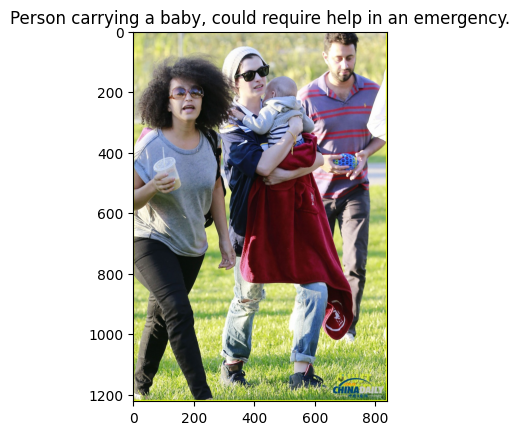

In [3]:
import matplotlib.pyplot as plt
plt.imshow(dataset[0]["image"])
plt.title(dataset[0]["text"])
plt.show()

In [1]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [3]:
from transformers import AutoProcessor, BlipForConditionalGeneration

processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

c:\Users\SeoJin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [6]:
from torch.utils.data import Dataset, DataLoader
from datasets import load_from_disk

# Assuming 'dataset' is already loaded from disk
# Split the dataset into training and evaluation sets
train_eval_split = dataset.train_test_split(test_size=0.1)
train_dataset = train_eval_split["train"]
eval_dataset = train_eval_split["test"]

train_dataset = ImageCaptioningDataset(train_dataset, processor)
eval_dataset = ImageCaptioningDataset(eval_dataset, processor)


train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=2)
eval_dataloader = DataLoader(eval_dataset, shuffle=False, batch_size=2) # Use a separate dataloader for evaluation

In [27]:
import torch
import os

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Create a directory for checkpoints
checkpoint_dir = "/content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(5):
    print("Epoch:", epoch + 1)
    model.train()
    train_loss = 0
    for idx, batch in enumerate(train_dataloader):
        input_ids = batch.pop("input_ids").to(device)
        pixel_values = batch.pop("pixel_values").to(device)
        attention_mask = batch.pop("attention_mask").to(device)

        outputs = model(
            input_ids=input_ids,
            pixel_values=pixel_values,
            attention_mask=attention_mask,
            labels=input_ids,
        )

        loss = outputs.loss
        train_loss += loss.item()

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        # Save checkpoint every 100 batches (or adjust as needed)
        if (idx + 1) % 250 == 0:
            checkpoint_path = os.path.join(
                checkpoint_dir, f"model_epoch_{epoch+1}_batch_{idx+1}_loss_{loss: .5f}.pt"
            )
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")


    print("Epoch Train Loss:", train_loss / len(train_dataloader))

    # Evaluation loop
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for idx, batch in enumerate(eval_dataloader): # Use the separate eval_dataloader
            input_ids = batch.pop("input_ids").to(device)
            pixel_values = batch.pop("pixel_values").to(device)
            attention_mask = batch.pop("attention_mask").to(device)

            outputs = model(
                input_ids=input_ids,
                pixel_values=pixel_values,
                attention_mask=attention_mask,
                labels=input_ids,
            )

            loss = outputs.loss
            eval_loss += loss.item()


    print("Epoch Eval Loss:", eval_loss / len(eval_dataloader)) # Calculate average eval loss


    # Save checkpoint at the end of each epoch
    checkpoint_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}_end_trainLoss_{train_loss / len(train_dataloader): .5f}_evalLoss_{eval_loss / len(train_dataloader): .5f}.pt")
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Checkpoint saved to {checkpoint_path}")

Epoch: 1


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_1_batch_250_loss_ 0.00257.pt
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_1_batch_500_loss_ 0.00266.pt
Epoch Train Loss: 0.003953623898697141
Epoch Eval Loss: 0.003558790951501578
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_1_end_trainLoss_ 0.00395_evalLoss_ 0.00040.pt
Epoch: 2
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_2_batch_250_loss_ 0.00248.pt
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_2_batch_500_loss_ 0.00152.pt
Epoch Train Loss: 0.0033793572307576057
Epoch Eval Loss: 0.0031163854726048105
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_2_end_trainLoss_ 0.00338_evalLoss_ 0.00035.pt
Epoch: 3
Checkpoint saved to /content/drive/MyDrive/All-Clear/vlm/vlm_checkpoints/model_epoch_3_batch_250_loss_ 0.000

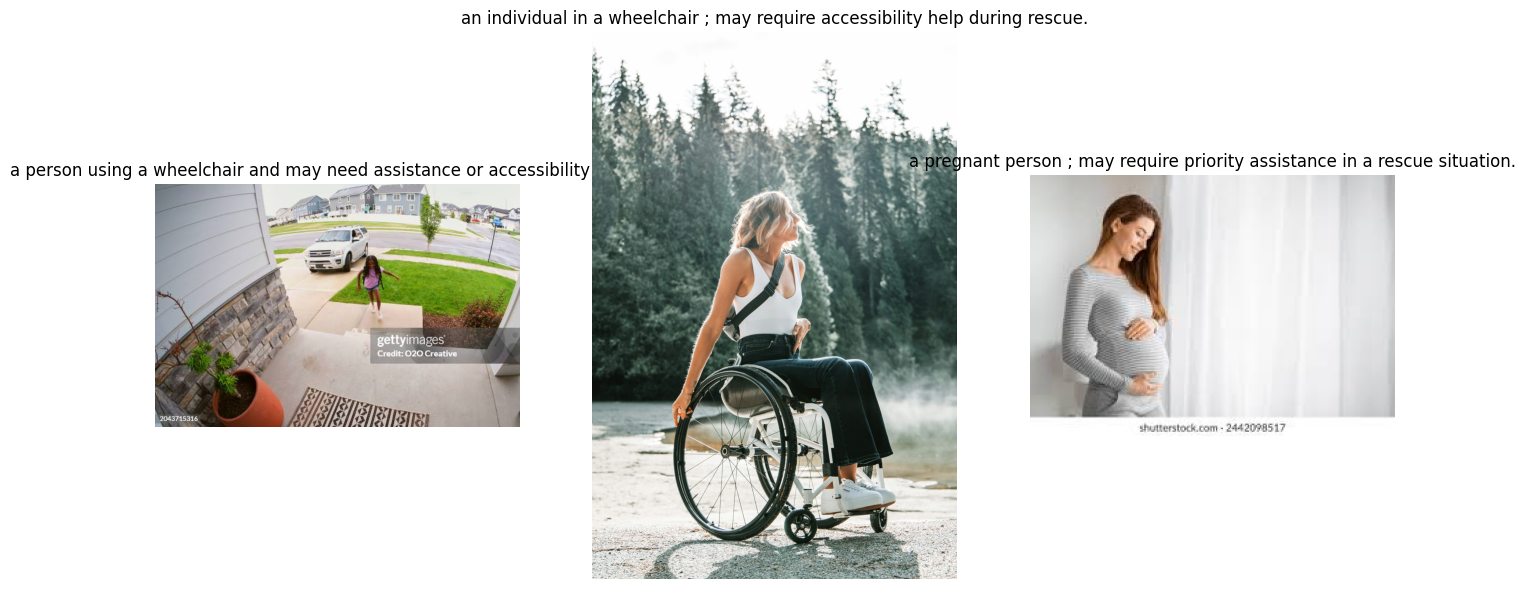

In [ ]:
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load a test image (you can replace this with your own image)
url_list = [
    "https://media.gettyimages.com/id/2043715316/photo/home-security-camera-footage-of-children-coming-and-going.jpg?s=612x612&w=gi&k=20&c=9x_cvMOqduzn1sh2DdpZYZupTdDAFcs8OQ-OxDYtLqw=",
    "https://images.unsplash.com/photo-1570793005299-c091be91bbad?ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8M3x8d2hlZWxjaGFpcnxlbnwwfHwwfHx8MA%3D%3D&fm=jpg&q=60&w=3000",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRGAE0_OUOd6TF2qr7dG333CH6a5hz8vBe5bQ&s"
    ]

#image = Image.open(requests.get(url, stream=True).raw)

# Load the trained model weights (replace with the path to your saved checkpoint)
checkpoint_path = "C:/Code_File/AllClear/All-Clear/vlm/vlm_checkpoints/model_epoch_2_batch_500_loss_ 0.00152.pt" # Replace with your checkpoint path
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))

# Set the model to evaluation mode
model.eval()

figure = plt.figure(figsize=(16, 8))
for i, img in enumerate(url_list):
    image = Image.open(requests.get(img, stream=True).raw)
    plt.subplot(1, len(url_list), i+1)

    # Prepare the image for the model
    inputs = processor(images=image, return_tensors="pt").to(device)

    # Generate a caption
    with torch.no_grad():
        outputs = model.generate(**inputs)

    # Decode and print the generated caption
    caption = processor.decode(outputs[0], skip_special_tokens=True)
    plt.imshow(image)
    plt.axis('off')
    plt.title(caption)
plt.show()